In [1]:
# =============================================================================
# 1. IMPORTS & LIBRARIES
# =============================================================================


# Standard libraries
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Scikit-learn libraries
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error, mean_absolute_percentage_error

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C
from sklearn.linear_model import Ridge, Lasso

# For better plot appearance
# %matplotlib inline

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)



In [ ]:
# =============================================================================
# 2. PREPROCESSING & SETUP (Tasks 1 - 6)
# =============================================================================


def load_and_preprocess(seed: int):

    # Task 1: Load the diabetes dataset
    diabetes_data = load_diabetes(as_frame=True, scaled=False)
    df = diabetes_data.frame.copy()

    # Task 2: Print the value range for one column (e.g., 'bmi')
    feature_name = "bmi"
    print(f"Feature '{feature_name}' range: min={df[feature_name].min():.3f}, max={df[feature_name].max():.3f}")
    print(" ")

    # Task 3: Check for NaN values and remove corresponding records
    print(f"Total NaN values before cleaning: {df.isna().sum().sum()}")
    print(" ")
    df_clean = df.dropna().reset_index(drop=True)

    # Task 4: Print (plot) a frequency graph (histogram) for the 'target' column
    plt.figure()
    plt.hist(df_clean["target"], bins=30)
    plt.title("Histogram of Target Variable")
    plt.xlabel("Disease Progression (mg/dL)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Prepare X and y
    X = df_clean.drop(columns=["target"]).values
    y = df_clean["target"].values.reshape(-1, 1)

    # Task 5: Normalize data (input and output) using Min-Max scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    # Task 6: Define a fixed seed number
    np.random.seed(seed)

    return X_scaled, y_scaled, df_clean, scaler_X, scaler_y, seed


Feature 'bmi' range: min=18.000, max=42.200
 
Total NaN values before cleaning: 0
 


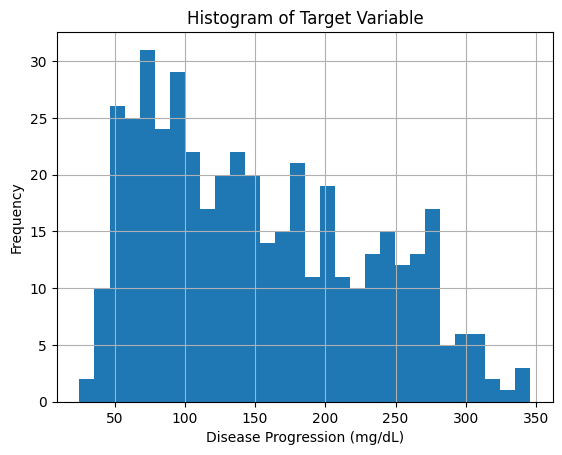

 
Dataset Loaded. Scaled X shape: (442, 10), Scaled y shape: (442, 1)
 


In [ ]:
# Task 6: Define a fixed seed (Global usage)
seed = 2025

# Execute load and preprocess
X_scaled, y_scaled, df_clean, scaler_X, scaler_y, seed_used = load_and_preprocess(seed)

print(" ")
print(f"Dataset Loaded. Scaled X shape: {X_scaled.shape}, Scaled y shape: {y_scaled.shape}")
print(" ")



In [ ]:
#Task 7: creation of KFold setup with 6 folds and seed
def get_kfold(seed):
    # We use shuffle=True to randomize based on the seed
    return KFold(n_splits=6, shuffle=True, random_state=seed)

#Task 9e: Calculates the 4 metrics.Because the function will be called for both scaled and raw data,it returns a dictionary with the results.
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    max_e = max_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {"RMSE": rmse, "MAE": mae, "Max": max_e, "MAPE": mape}

#Task 9g: Adds a row to csv_data with the correct column order
def append_csv_row(csv_data, model_name, set_type, fold, metrics_n, metrics_raw):
    row = [
        model_name,set_type,fold,
        metrics_n["Max"], metrics_n["RMSE"], metrics_n["MAE"], metrics_n["MAPE"],
        metrics_raw["Max"], metrics_raw["RMSE"], metrics_raw["MAE"], metrics_raw["MAPE"]
    ]
    csv_data.append(row)

#Task 9f: we create the chart Actual vs Predicted
def plot_actual_vs_predicted(y_true, y_pred, model_name, fold, set_type):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, color='blue', label='Predictions')

    #Drawing the ideal line (y=x)
    limits = [
        np.min([y_true.min(), y_pred.min()]),
        np.max([y_true.max(), y_pred.max()])
    ]
    plt.plot(limits, limits, color='red', linestyle='--', label='Ideal')

    plt.title(f"Actual vs Predicted - {model_name}\nFold {fold} ({set_type} set)")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True)

    #Save to PNG
    filename = f"actual_vs_pred_{model_name}_fold{fold}_{set_type}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    #Show output
    plt.show()

    plt.close()

In [ ]:
# Task 8: Create a list named csv_data to store the results
csv_data = []
# Task 8: Append header row
csv_data.append(["Model", "Set", "Fold", "Max_n", "RMSE_n", "MAE_n", "MAPE_n", "Max", "RMSE", "MAE", "MAPE"])


Starting Fold 1
 



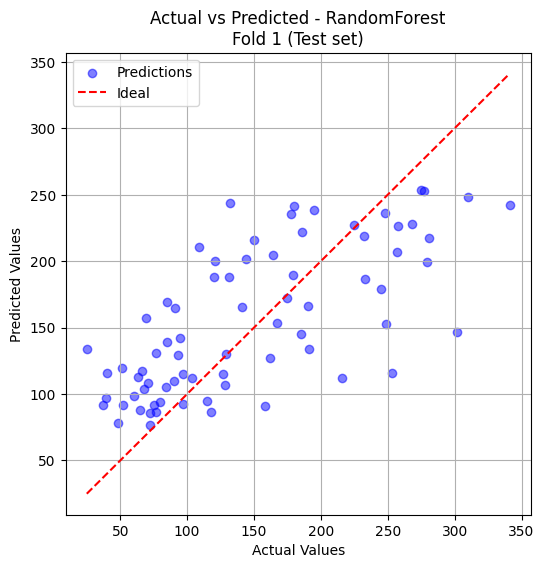

ExactExplainer explainer: 75it [00:26,  1.94it/s]



Starting Fold 2
 



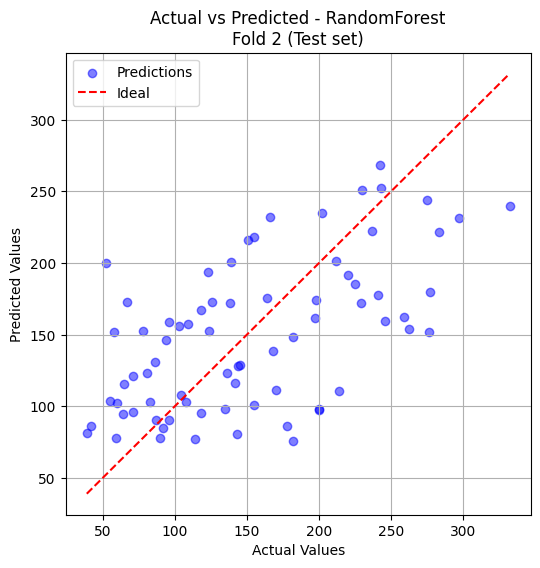


Starting Fold 3
 



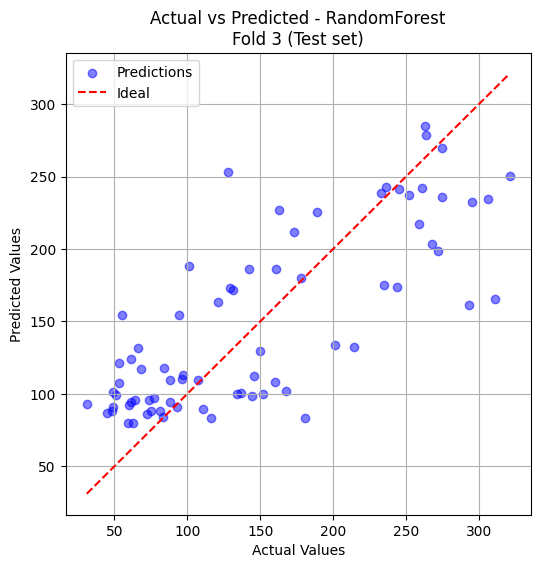


Starting Fold 4
 



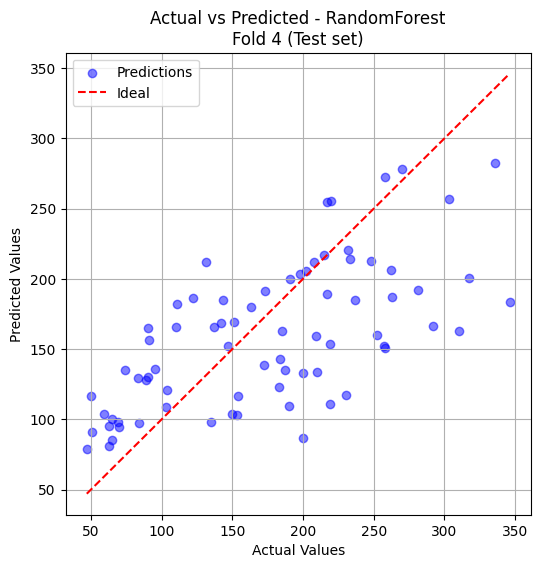


Starting Fold 5
 



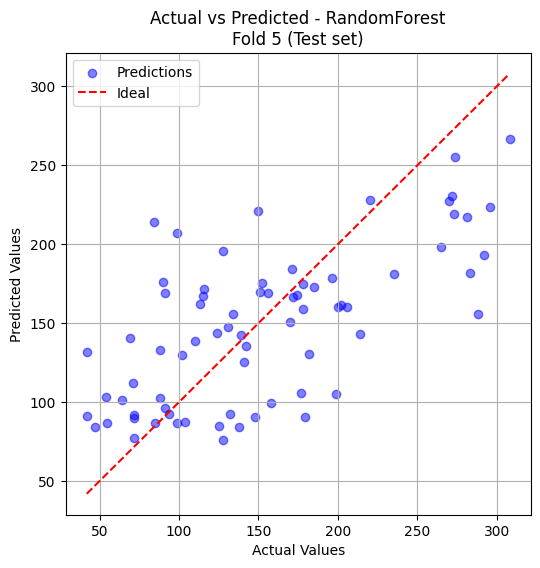

ExactExplainer explainer: 74it [00:17,  1.73it/s]



Starting Fold 6
 



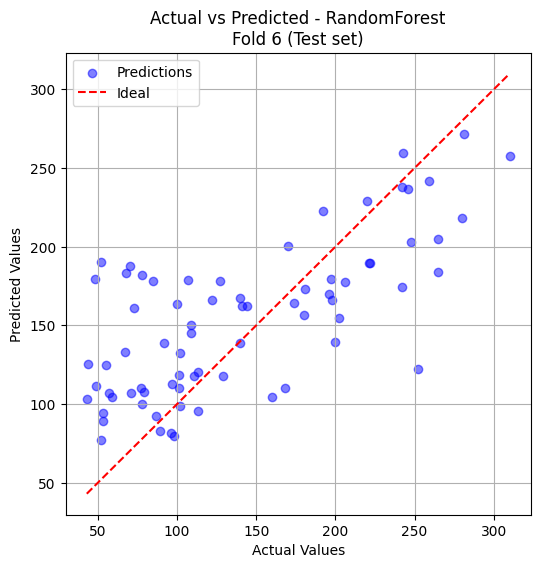

 
Random Forest calculations finished and added to list.


In [ ]:
# =============================================================================
# MODEL 1: RANDOM FOREST REGRESSOR (Task 9)
# =============================================================================

# Task 7: K-Fold Cross Validation Loop


kfold = get_kfold(seed)

fold = 1

# Task 9: Start executing a for loop based on the kfold setup
for train_idx, test_idx in kfold.split(X_scaled):

    print(f"\nStarting Fold {fold}")
    print(" \n") # Κενό για διαχωρισμό στα αποτελέσματα

    # Task 9a: Split data into train and test for the current fold
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

    # Task 9a: Model definition (Random Forest Regressor)
    model = RandomForestRegressor(random_state=seed)

    # Task 9b: Hyperparameter tuning using RandomizedSearchCV
    param_dist = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=seed,
        n_jobs=-1
    )

    # Task 9a: Train the model on the training data of the current fold
    random_search.fit(X_train, y_train.ravel())

    # Task 9b: Get the best model found by RandomizedSearchCV
    best_model = random_search.best_estimator_

    # Task 9c: Predictions on train and test sets (scaled)
    y_train_pred_scaled = best_model.predict(X_train).reshape(-1, 1)
    y_test_pred_scaled = best_model.predict(X_test).reshape(-1, 1)


    # Task 9d: Denormalization (inverse Min-Max scaling)
    y_train_true = scaler_y.inverse_transform(y_train)
    y_test_true = scaler_y.inverse_transform(y_test)

    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

    # Task 9e: 1. Calculating metrics for the Test Set (scaled and raw)
    metrics_n = compute_metrics(y_test, y_test_pred_scaled) # Normalized
    metrics_raw = compute_metrics(y_test_true, y_test_pred) # Initial values

    # Task 9g: 2. Save the row to CSV for the Test Set
    append_csv_row(csv_data, "RandomForest", "Test", fold, metrics_n, metrics_raw)

    # Task 9g: 3. We do the same for the Train Set
    metrics_train_n = compute_metrics(y_train, y_train_pred_scaled)
    metrics_train_raw = compute_metrics(y_train_true, y_train_pred)
    append_csv_row(csv_data, "RandomForest", "Train", fold, metrics_train_n, metrics_train_raw)

    # Task 9f: 4. Show the graph for this fold
    plot_actual_vs_predicted(y_test_true, y_test_pred, "RandomForest", fold, "Test")

    # Task 9h: ================= SHAP for Random Forest =================

    explainer = shap.Explainer(best_model.predict, X_train)
    shap_values = explainer(X_test)

    # Task 9h: SHAP summary plot
    shap.summary_plot(
      shap_values,
      X_test,
      feature_names=None,
      show=False
    )
    plt.savefig(f"shap_summary_RandomForest_fold{fold}_test.png")
    plt.close()

    # Task 9h: SHAP waterfall plots (2 examples)
    for idx in [0, 1]:
       shap.plots.waterfall(shap_values[idx], show=False)
       plt.savefig(f"shap_waterfall_RandomForest_fold{fold}_ex{idx}.png")
       plt.close()


    fold += 1


print(" ")
print("Random Forest calculations finished and added to list.")


Starting Fold 1 - Gaussian Process Regression




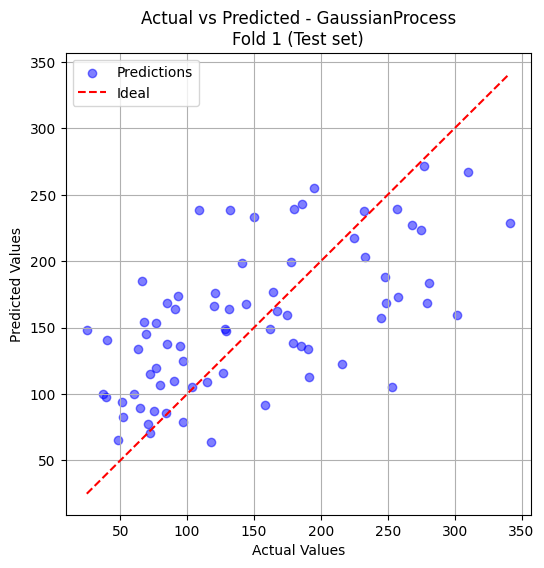

ExactExplainer explainer: 75it [02:44,  2.35s/it]



Starting Fold 2 - Gaussian Process Regression




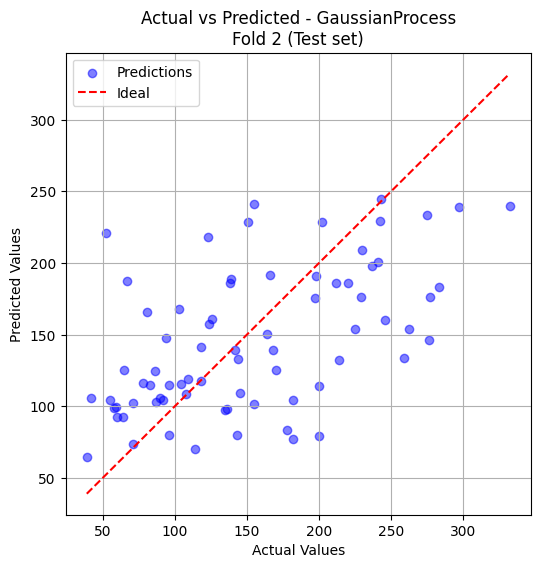

ExactExplainer explainer: 75it [02:40,  2.29s/it]



Starting Fold 3 - Gaussian Process Regression




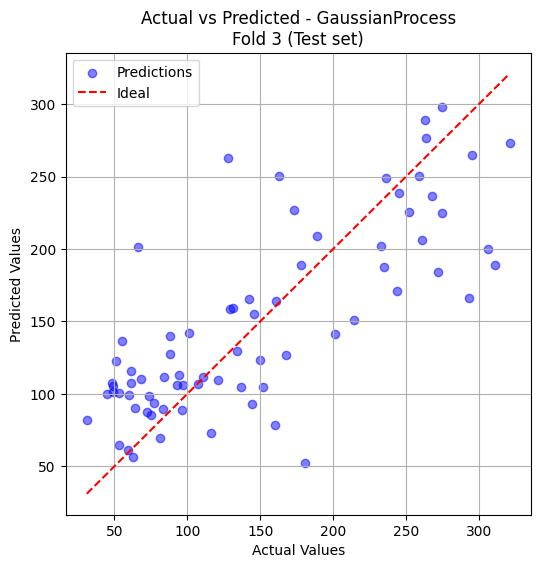

ExactExplainer explainer: 75it [02:42,  2.32s/it]



Starting Fold 4 - Gaussian Process Regression




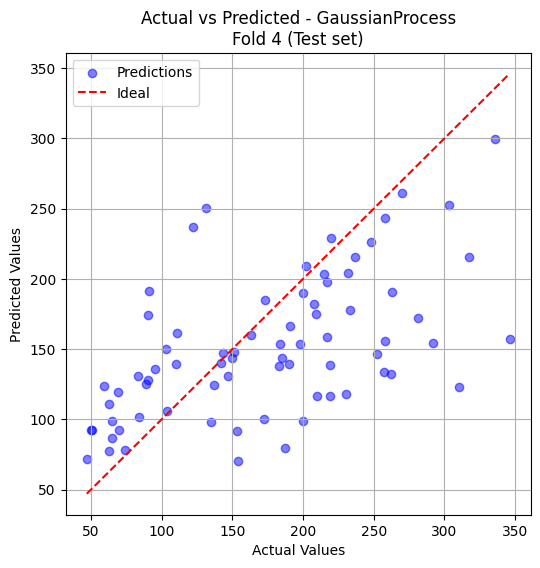

ExactExplainer explainer: 75it [02:41,  2.31s/it]



Starting Fold 5 - Gaussian Process Regression




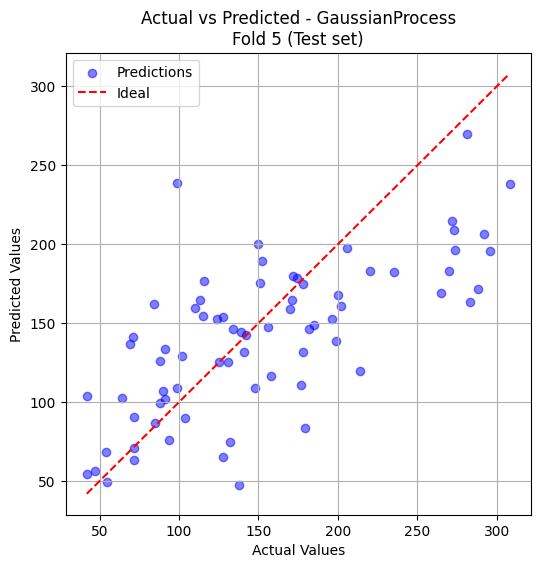

ExactExplainer explainer: 74it [02:51,  2.48s/it]



Starting Fold 6 - Gaussian Process Regression




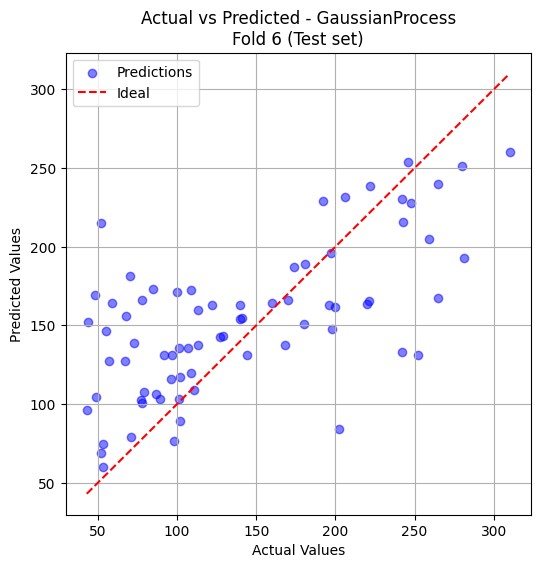

ExactExplainer explainer: 74it [02:43,  2.37s/it]


Gaussian Process calculations finished and added to list.


In [ ]:
# =============================================================================
# MODEL 2: GAUSSIAN PROCESS REGRESSOR (Task 9)
# =============================================================================

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C
from sklearn.model_selection import RandomizedSearchCV

# Task 7: K-Fold Cross Validation
kfold = get_kfold(seed)

fold = 1
# Task 9: Start executing a for loop based on the kfold setup
for train_idx, test_idx in kfold.split(X_scaled):

    print(f"\nStarting Fold {fold} - Gaussian Process Regression")
    print("\n")

    # Task 9a: Split data into train and test for the current fold
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]


    # Task 9a: Gaussian Process Regressor definition
    kernel = C(1.0) * RBF(length_scale=1.0)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        random_state=seed
    )


    # Task 9b: Hyperparameter tuning with RandomizedSearchCV
    param_dist = {
        "kernel": [
            C(1.0) * RBF(length_scale=l)
            for l in [0.1, 0.5, 1.0, 2.0]
        ] + [
            C(1.0) * Matern(length_scale=l, nu=1.5)
            for l in [0.5, 1.0, 2.0]
        ],
        "alpha": [1e-10, 1e-5, 1e-3, 1e-1]
    }

    random_search = RandomizedSearchCV(
        estimator=gpr,
        param_distributions=param_dist,
        n_iter=5,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=seed,
        n_jobs=-1
    )

    # Task 9a: Train the model on the training data of the current fold
    random_search.fit(X_train, y_train.ravel())

    # Task 9b: Get the best model found by RandomizedSearchCV
    best_model = random_search.best_estimator_


    # Task 9c: Predictions (scaled)
    y_train_pred_scaled = best_model.predict(X_train).reshape(-1, 1)
    y_test_pred_scaled = best_model.predict(X_test).reshape(-1, 1)


    # Task 9d: Denormalization
    y_train_true = scaler_y.inverse_transform(y_train)
    y_test_true = scaler_y.inverse_transform(y_test)

    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

    # Task 9e: Calculating metrics for the Test Set (scaled and raw)
    metrics_n = compute_metrics(y_test, y_test_pred_scaled)
    metrics_raw = compute_metrics(y_test_true, y_test_pred)

    # Task 9g: Save the row to CSV for the Test Set
    append_csv_row(csv_data, "GaussianProcess", "Test", fold, metrics_n, metrics_raw)

    # Task 9g: We do the same for the Train Set
    metrics_train_n = compute_metrics(y_train, y_train_pred_scaled)
    metrics_train_raw = compute_metrics(y_train_true, y_train_pred)
    append_csv_row(csv_data, "GaussianProcess", "Train", fold, metrics_train_n, metrics_train_raw)

    # Task 9f: Show the graph for this fold
    plot_actual_vs_predicted(y_test_true, y_test_pred, "GaussianProcess", fold, "Test")


    # Task 9h: ================= SHAP for Gaussian Process =================

    explainer = shap.Explainer(best_model.predict, X_train)
    shap_values = explainer(X_test)

    # Task 9h: SHAP summary plot
    shap.summary_plot(
      shap_values,
      X_test,
      feature_names=None,
      show=False
    )
    plt.savefig(f"shap_summary_GaussianProcess_fold{fold}_test.png")
    plt.close()

    # Task 9h: SHAP waterfall plots (2 examples)
    for idx in [0, 1]:
       shap.plots.waterfall(
          shap_values[idx],
          show=False
       )
       plt.savefig(f"shap_waterfall_GaussianProcess_fold{fold}_ex{idx}.png")
       plt.close()

    fold += 1

print("Gaussian Process calculations finished and added to list.")


Starting Fold 1




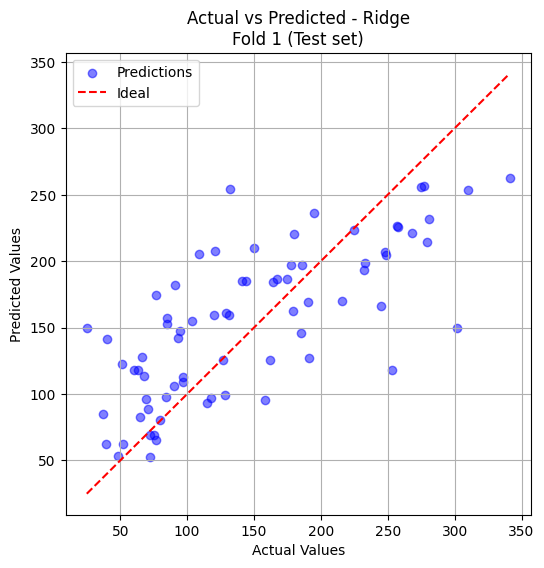


Starting Fold 2




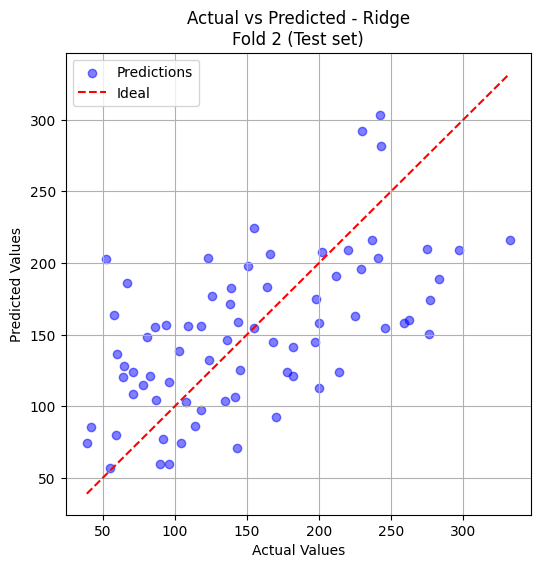


Starting Fold 3




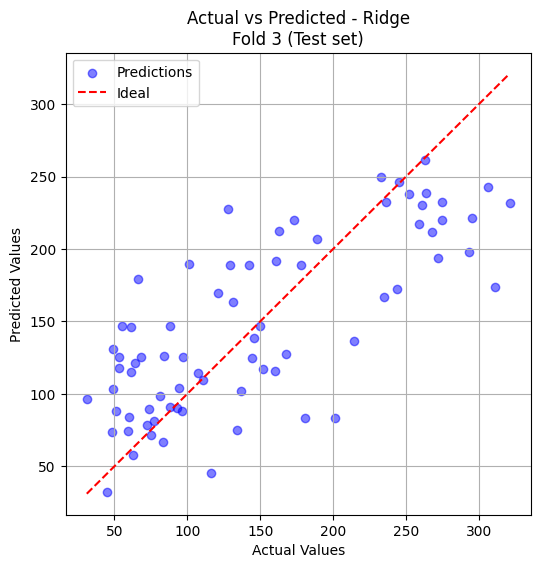


Starting Fold 4




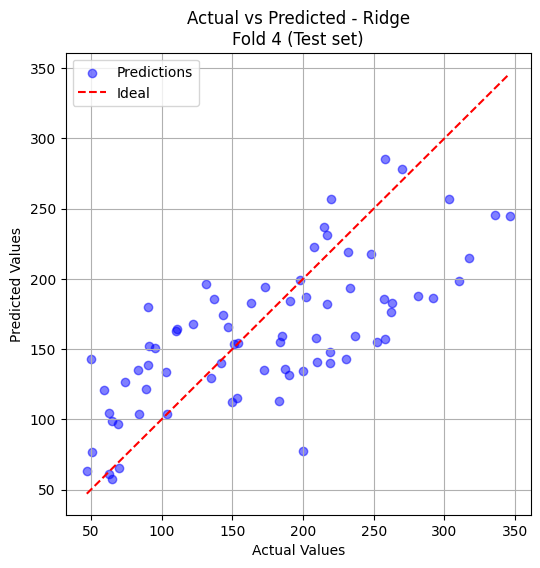


Starting Fold 5




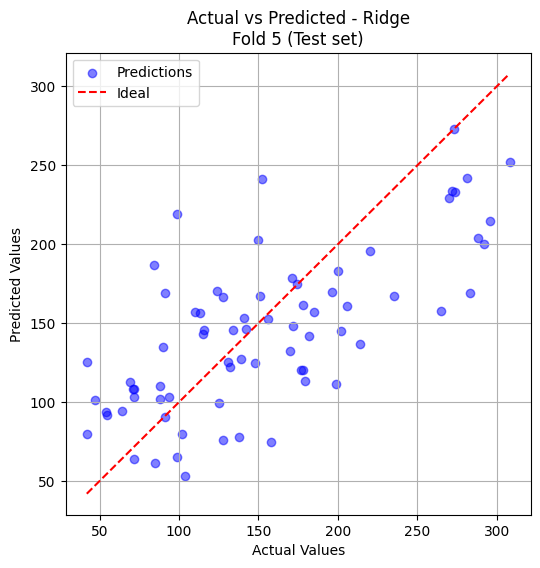


Starting Fold 6




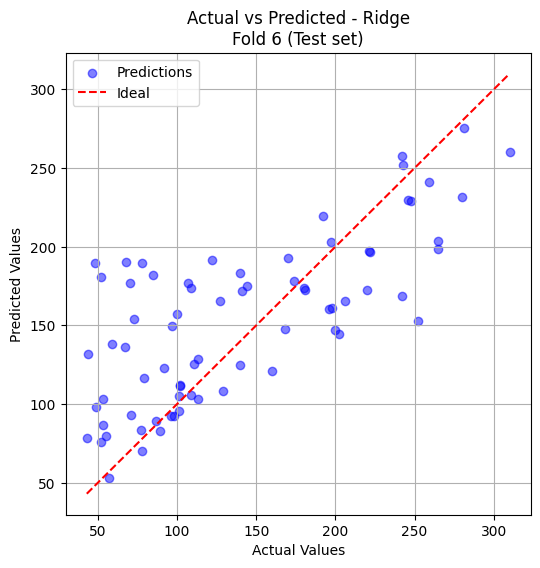

Ridge Regression folds completed and added to list.


In [ ]:
# =============================================================================
# MODEL 3: RIDGE REGRESSION (Task 9)
# =============================================================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV

# Task 7: K-Fold Cross Validation
kfold = get_kfold(seed)

fold = 1
# Task 9: Start executing a for loop based on the kfold setup
for train_idx, test_idx in kfold.split(X_scaled):

    print(f"\nStarting Fold {fold}")
    print("\n")

    # Task 9a: Split data into train and test for the current fold
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

    # Task 9a: Model definition (Ridge Regression)
    model = Ridge(random_state=seed)

    # Task 9b: Hyperparameter tuning using RandomizedSearchCV
    param_dist = {
        "alpha": np.logspace(-4, 4, 100)
    }

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=seed,
        n_jobs=-1
    )

    # Task 9a: Train the model on the training data of the current fold
    random_search.fit(X_train, y_train.ravel())

    # Task 9b: Best model
    best_model = random_search.best_estimator_

    # Task 9c: Predictions on train and test sets (scaled)
    y_train_pred_scaled = best_model.predict(X_train).reshape(-1, 1)
    y_test_pred_scaled = best_model.predict(X_test).reshape(-1, 1)

    # Task 9d: Denormalization (inverse Min-Max scaling)
    y_train_true = scaler_y.inverse_transform(y_train)
    y_test_true = scaler_y.inverse_transform(y_test)

    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

    # Task 9e: Calculating metrics for the Test Set (scaled and raw)
    metrics_n = compute_metrics(y_test, y_test_pred_scaled)
    metrics_raw = compute_metrics(y_test_true, y_test_pred)

    # Task 9g: Save the row to csv for the Test Set
    append_csv_row(csv_data, "Ridge", "Test", fold, metrics_n, metrics_raw)

    # Task 9g: We do the same for the Train Set
    metrics_train_n = compute_metrics(y_train, y_train_pred_scaled)
    metrics_train_raw = compute_metrics(y_train_true, y_train_pred)
    append_csv_row(csv_data, "Ridge", "Train", fold, metrics_train_n, metrics_train_raw)

    # Task 9f: Show the graph for this fold
    plot_actual_vs_predicted(y_test_true, y_test_pred, "Ridge", fold, "Test")


    # Task 9h: ================= SHAP for Ridge Regression =================
    try:
        explainer = shap.LinearExplainer(best_model, X_train)
        shap_values = explainer(X_test)

        # Task 9h: SHAP summary plot
        plt.figure()
        shap.summary_plot(shap_values, X_test, show=False)
        plt.title(f"Task 9h: SHAP Summary - Ridge Fold {fold}")
        plt.savefig(f"shap_summary_Ridge_fold{fold}_test.png")
        plt.close()

        # Task 9h: SHAP waterfall plots (2 examples)
        for idx in [0, 1]:
            plt.figure()
            shap.plots.waterfall(shap_values[idx], show=False)
            plt.title(f"Task 9h: SHAP Waterfall - Ridge Fold {fold} Ex {idx}")
            plt.savefig(f"shap_waterfall_Ridge_fold{fold}_ex{idx}.png")
            plt.close()
    except Exception as e:
        print(f"SHAP Error for Ridge Fold {fold}: {e}")

    fold += 1

print("Ridge Regression folds completed and added to list.")


Starting Fold 1




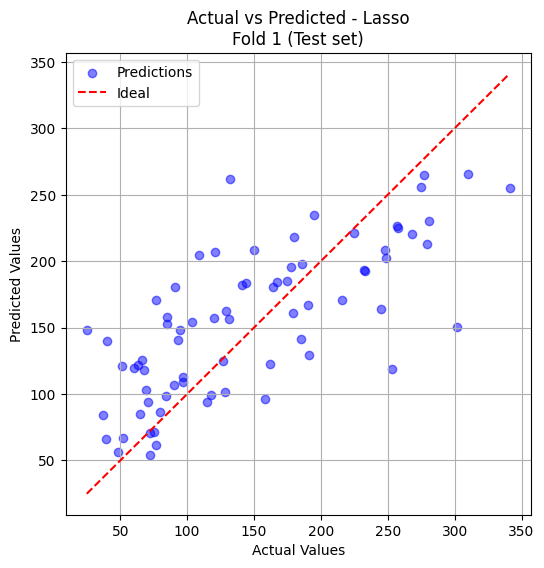


Starting Fold 2




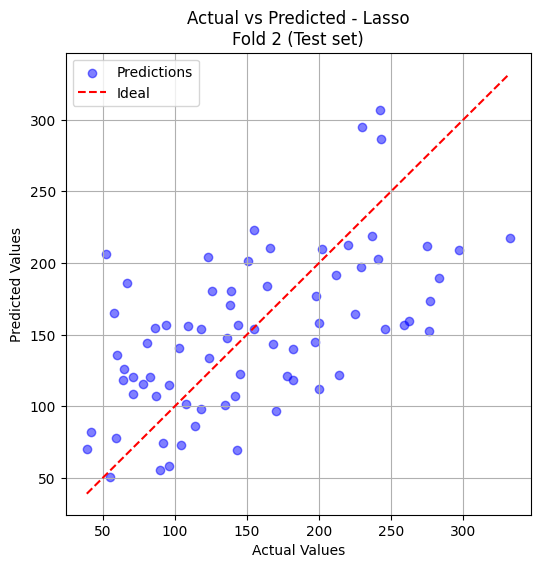


Starting Fold 3




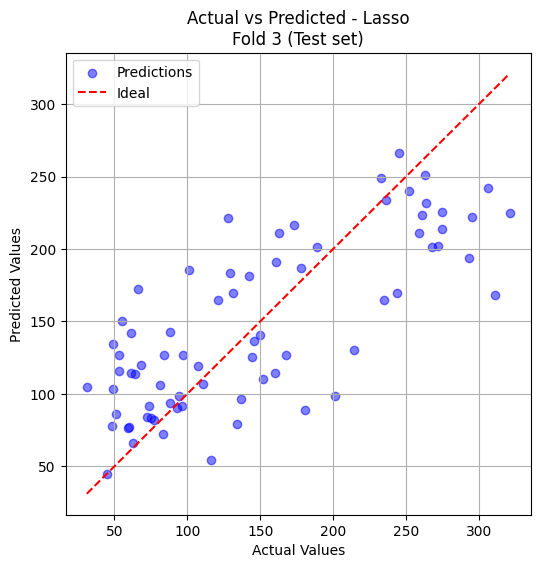


Starting Fold 4




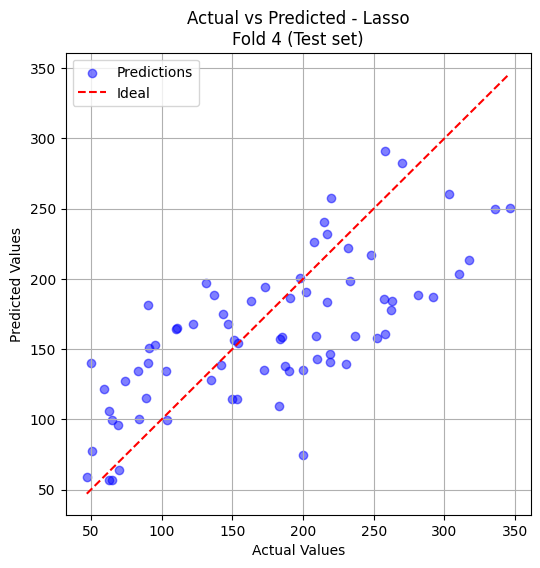


Starting Fold 5




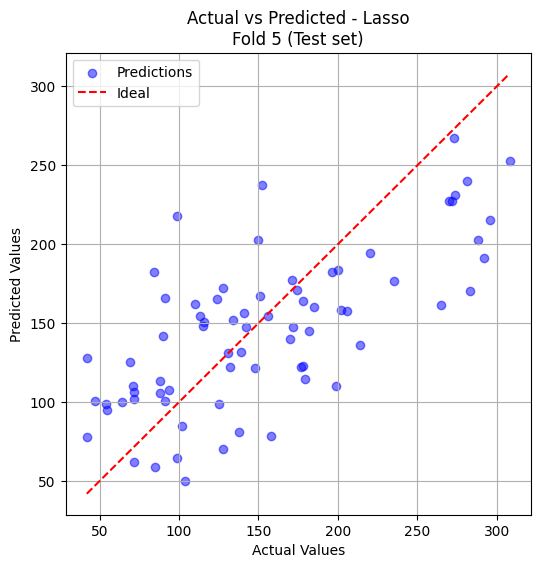


Starting Fold 6




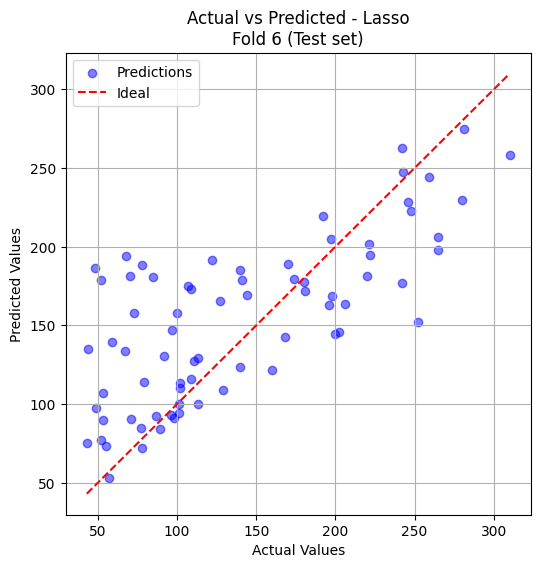

Lasso Regression folds completed and metrics added to list.


In [ ]:
# =============================================================================
# MODEL 4: LASSO REGRESSION (Task 9)
# =============================================================================

from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV

# Task 7: K-Fold Cross Validation
kfold = get_kfold(seed)

fold = 1
# Task 9: Start executing a for loop based on the kfold setup
for train_idx, test_idx in kfold.split(X_scaled):

    print(f"\nStarting Fold {fold}")
    print("\n")


    # Task 9a: Split data into train and test for the current fold
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

    # Task 9a: Model definition (Lasso Regression)
    model = Lasso(random_state=seed, max_iter=10000)

    # Task 9b: Hyperparameter tuning using RandomizedSearchCV
    param_dist = {
        "alpha": np.logspace(-4, 1, 100)
    }

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=seed,
        n_jobs=-1
    )

    # Task 9a: Train the model on the training data of the current fold
    random_search.fit(X_train, y_train.ravel())

    # Task 9b: Best model
    best_model = random_search.best_estimator_

    # Task 9c: Predictions on train and test sets (scaled)
    y_train_pred_scaled = best_model.predict(X_train).reshape(-1, 1)
    y_test_pred_scaled = best_model.predict(X_test).reshape(-1, 1)

    # Task 9d: Denormalization (inverse Min-Max scaling)
    y_train_true = scaler_y.inverse_transform(y_train)
    y_test_true = scaler_y.inverse_transform(y_test)

    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

    # Task 9e: Calculating metrics for the Test Set (scaled and raw)
    metrics_n = compute_metrics(y_test, y_test_pred_scaled)
    metrics_raw = compute_metrics(y_test_true, y_test_pred)

    # Task 9g: Save the row to csv for the Test Set
    append_csv_row(csv_data, "Lasso", "Test", fold, metrics_n, metrics_raw)

    # Task 9g: We do the same for the Train Set
    metrics_train_n = compute_metrics(y_train, y_train_pred_scaled)
    metrics_train_raw = compute_metrics(y_train_true, y_train_pred)
    append_csv_row(csv_data, "Lasso", "Train", fold, metrics_train_n, metrics_train_raw)

    # Task 9f: Show the graph for this fold
    plot_actual_vs_predicted(y_test_true, y_test_pred, "Lasso", fold, "Test")


    # Task 9h: ================= SHAP for Lasso Regression =================
    try:
        explainer = shap.LinearExplainer(best_model, X_train)
        shap_values = explainer(X_test)

        # Task 9h: SHAP summary plot
        plt.figure()
        shap.summary_plot(shap_values, X_test, show=False)
        plt.title(f"Task 9h: SHAP Summary - Lasso Fold {fold}")
        plt.savefig(f"shap_summary_Lasso_fold{fold}_test.png")
        plt.close()

        # Task 9h: SHAP waterfall plots (2 examples)
        for idx in [0, 1]:
            plt.figure()
            shap.plots.waterfall(shap_values[idx], show=False)
            plt.title(f"Task 9h: SHAP Waterfall - Lasso Fold {fold} Ex {idx}")
            plt.savefig(f"shap_waterfall_Lasso_fold{fold}_ex{idx}.png")
            plt.close()
    except Exception as e:
        print(f"SHAP Error for Lasso Fold {fold}: {e}")


    fold += 1

print("Lasso Regression folds completed and metrics added to list.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =============================================================================
# EXPORT RESULTS
# =============================================================================

# Export to CSV
results_df = pd.DataFrame(csv_data[1:], columns=csv_data[0])
results_df.to_csv("results.csv", index=False)
print("\nSuccess! 'results.csv' generated with data from all 4 models.")
print(results_df.head())



Success! 'results.csv' generated with data from all 4 models.
          Model    Set  Fold     Max_n    RMSE_n     MAE_n        MAPE_n  \
0  RandomForest   Test     1  0.484538  0.178578  0.146591  2.062359e+13   
1  RandomForest  Train     1  0.300772  0.107293  0.085308  3.767822e-01   
2  RandomForest   Test     2  0.460442  0.184660  0.154493  6.198595e-01   
3  RandomForest  Train     2  0.361084  0.128014  0.104916  2.812574e+12   
4  RandomForest   Test     3  0.453419  0.163886  0.133411  7.202375e-01   

          Max       RMSE        MAE      MAPE  
0  155.536818  57.323475  47.055620  0.466069  
1   96.547786  34.441086  27.383989  0.238557  
2  147.801755  59.275957  49.592378  0.413283  
3  115.907977  41.092454  33.677947  0.304587  
4  145.547656  52.607397  42.824881  0.403720  
